# 导入库

In [77]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# 定义目标函数 $y = \sin(x) + 0.3\cos(3x)$

In [78]:
# 定义目标函数
def target_function(x):
    return np.sin(x) + 0.3*np.cos(3*x)

# 生成数据集

In [79]:
# 在区间[-5,5]采样
x = np.linspace(-5,5,1200)

y = target_function(x)

# reshape为神经网络输入格式
x = x.reshape(-1,1)
y = y.reshape(-1,1)

# 划分训练和测试
train_size = 1000

x_train = x[:train_size]
y_train = y[:train_size]

x_test = x[train_size:]
y_test = y[train_size:]

print("Train:",x_train.shape)
print("Test:",x_test.shape)

Train: (1000, 1)
Test: (200, 1)


# 数据可视化

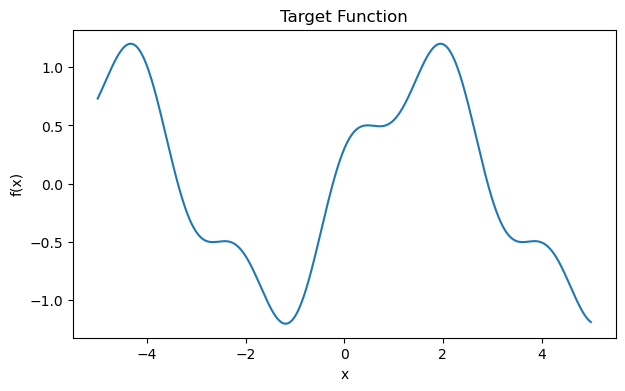

In [80]:
plt.figure(figsize=(7,4))

plt.plot(x,y)

plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.show()

# 建立ReLU网络

In [81]:
model = tf.keras.Sequential([

    tf.keras.Input(shape=(1,)),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1
    )
])

# 建立并训练模型

In [82]:
from tensorflow.keras import callbacks

# 定义早停回调
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',      # 监控验证集损失
    patience=30,             # 耐心值：连续多少个epoch验证损失没有改善就停止
    restore_best_weights=True,  # 是否恢复最佳模型权重
    verbose=1                # 打印早停信息
)
# 定义余弦学习率衰减
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(

    initial_learning_rate=0.01,

    decay_steps=300

)
model.compile(
    #AdamW优化器，结合了Adam优化器的自适应学习率和权重衰减的正则化效果
    optimizer = tf.keras.optimizers.AdamW(

    learning_rate=0.001,

    weight_decay=1e-4

),

    loss='mse',

    metrics=['mae']

)

model.summary()
history = model.fit(

    x_train,
    y_train,

    epochs=300,
    batch_size=32,

    validation_data=(x_test,y_test),
    callbacks=[early_stopping],  # 添加早停回调

    verbose=1

)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,089 (98.00 KB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4661 - mae: 0.6025 - val_loss: 3.2433 - val_mae: 1.7685
Epoch 2/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3571 - mae: 0.5193 - val_loss: 3.0789 - val_mae: 1.7277
Epoch 3/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1869 - mae: 0.3534 - val_loss: 1.6515 - val_mae: 1.2659
Epoch 4/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0898 - mae: 0.2233 - val_loss: 0.8735 - val_mae: 0.9157
Epoch 5/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0682 - mae: 0.1968 - val_loss: 0.4098 - val_mae: 0.6132
Epoch 6/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0552 - mae: 0.1782 - val_loss: 0.1809 - val_mae: 0.3884
Epoch 7/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0442 - mae: 0.1586 - val_loss: 0.0726 - val_mae: 0.2185
Epoch 8/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0367 - mae: 0.1397 - val_loss: 0.0295 - val_mae: 0.1208
Epoch 9/300
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.031

# 训练误差曲线

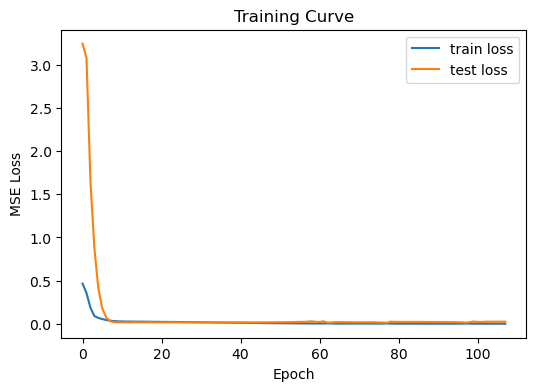

In [83]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'],label="train loss")
plt.plot(history.history['val_loss'],label="test loss")

plt.legend()

plt.title("Training Curve")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

# 预测

In [84]:
y_pred = model.predict(x)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


# 结果可视化

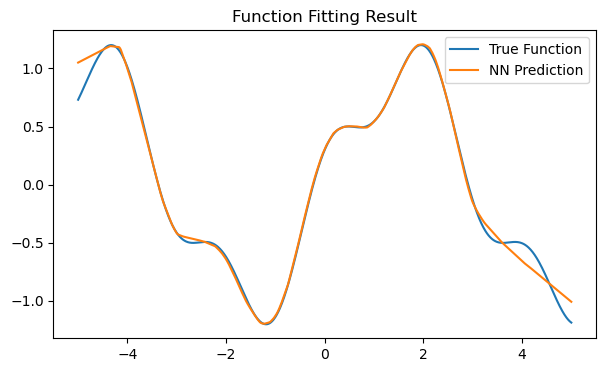

In [85]:
plt.figure(figsize=(7,4))

plt.plot(x,y,label="True Function")
plt.plot(x,y_pred,label="NN Prediction")

plt.legend()

plt.title("Function Fitting Result")

plt.show()

# 误差分析

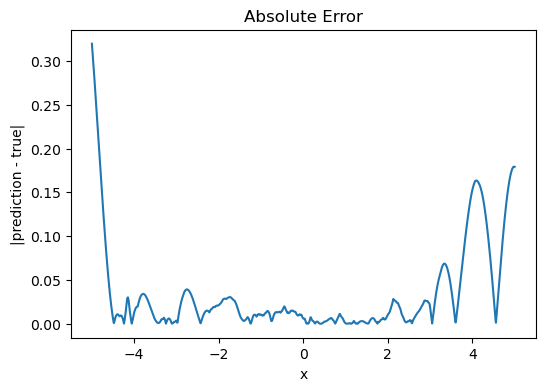

In [86]:
error = np.abs(y_pred - y)

plt.figure(figsize=(6,4))

plt.plot(x,error)

plt.title("Absolute Error")

plt.xlabel("x")
plt.ylabel("|prediction - true|")

plt.show()